PREPARACIÓN DE LOS DATOS

In [1]:
#Importamos las librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_curve, roc_auc_score, precision_recall_curve, average_precision_score,
    confusion_matrix, precision_score, recall_score, f1_score
)

# Ajustes de gráfico (opcional): tamaño por defecto
plt.rcParams['figure.figsize'] = (8, 5)

In [6]:
#Lectura del CSV
archivo = "Retention_Tec_versión clase_v2.csv"
df = pd.read_csv(archivo)

print("Dimensiones del dataset:", df.shape)  # filas, columnas
display(df.head())  # vista previa de las primeras filas

#Revisión rápida de valores nulos (buena práctica antes de modelar)
print('Valores nulos por columna:')
display(df.isna().sum())

#Vemos el tipo de datos de cada columna
print('Tipos de datos por columna:')
display(df.dtypes)

Dimensiones del dataset: (6620, 6)


,Abandono,Gender,Age,High_School_GPA,Language_Level,Toefl
0,0,1,26,87.00,8,637
1,1,1,24,75.12,7,590
2,1,1,24,84.57,7,593
3,1,0,23,88.83,8,617
4,1,1,23,85.14,8,613


Valores nulos por columna:


Abandono           0
Gender             0
Age                0
High_School_GPA    0
Language_Level     0
Toefl              0
dtype: int64

Tipos de datos por columna:


Abandono             int64
Gender               int64
Age                  int64
High_School_GPA    float64
Language_Level       int64
Toefl                int64
dtype: object

SELECCIÓN DE VARIABLES 

- **X**: características/variables independientes.  
- **y**: variable objetivo (**`Abandono`**).  

In [7]:
# Columnas predictoras (deben existir con estos nombres exactos)
feature_cols = ['Gender', 'Age', 'High_School_GPA', 'Language_Level','Toefl']
target_col = "Abandono"

# X = predictores; y = objetivo binario
X = df[feature_cols].copy()
y = df[target_col].astype(int).copy()

# División entrenamiento/prueba (estratificado para mantener proporción de clases)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print("Tamaños:")
print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("y_train:", y_train.shape, "| y_test:", y_test.shape)


Tamaños:
X_train: (4634, 5) | X_test: (1986, 5)
y_train: (4634,) | y_test: (1986,)


EJECUCIÓN DEL ANÁLISIS DE COMPONENTES PRINCIPALES

Entrenar el modelo (Pipeline: Estandarización + Regresión Logística)

- **¿Por qué estandarizar?** Para que todas las variables numéricas tengan escala comparable (media≈0, desvío≈1).  
- **Regresión logística**: estima la probabilidad de abandono para cada cliente.  
- **Salida**: `predict_proba` nos da la **probabilidad** (no solo 0/1).


In [8]:
# Pipeline con StandardScaler + LogisticRegression
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=500, solver="lbfgs"))
])

pipe.fit(X_train, y_train)

# Probabilidades predichas para el conjunto de prueba (clase 1 = abandono)
y_scores = pipe.predict_proba(X_test)[:, 1]

# Métricas generales de probabilidad
roc_auc = roc_auc_score(y_test, y_scores)
ap = average_precision_score(y_test, y_scores)
print(f"AUC ROC: {roc_auc:.3f} | AP (Área bajo curva Precisión–Recall): {ap:.3f}")


AUC ROC: 0.636 | AP (Área bajo curva Precisión–Recall): 0.098


Curvas ROC y Precisión–Recall
- **ROC**: muestra la relación entre TPR (sensibilidad) y FPR (falsos positivos) a distintos umbrales.  
- **Precisión–Recall**: útil cuando las clases están desbalanceadas.  
- **Gráfico Precisión/Recall vs Umbral**: ayuda a escoger el umbral según la prioridad (evitar falsos negativos o falsos positivos).


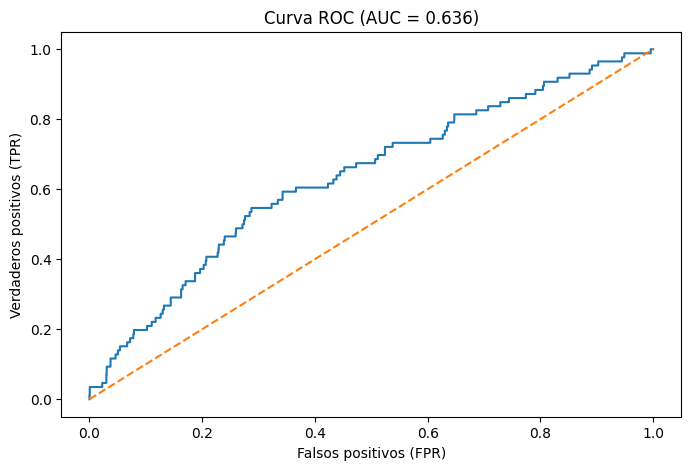

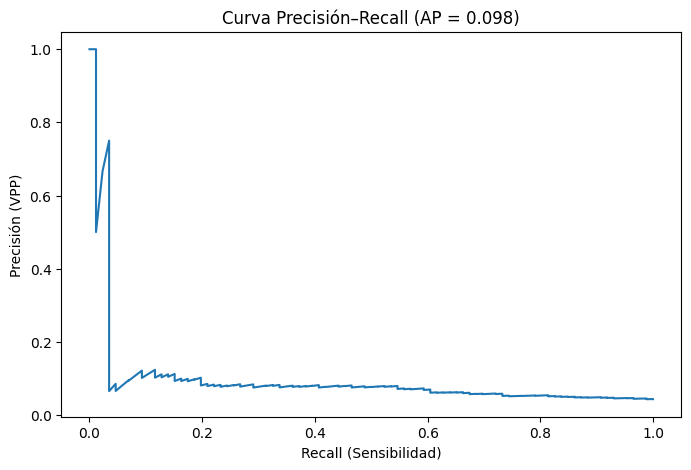

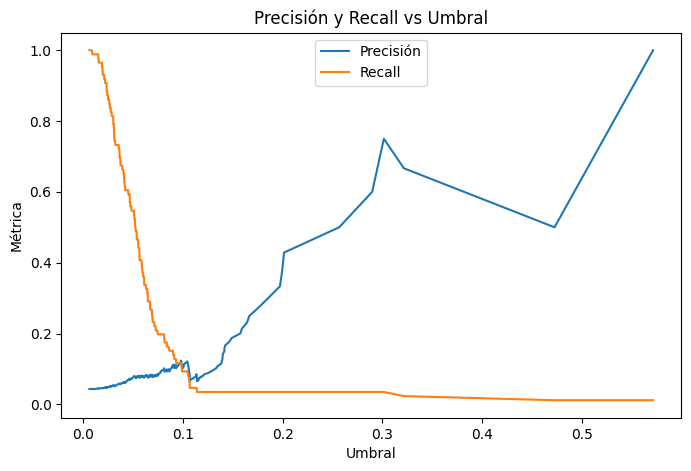

In [9]:
# --- Curva ROC ---
fpr, tpr, roc_thresholds = roc_curve(y_test, y_scores)
plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("Falsos positivos (FPR)")
plt.ylabel("Verdaderos positivos (TPR)")
plt.title(f"Curva ROC (AUC = {roc_auc:.3f})")
plt.show()

# --- Curva Precisión–Recall ---
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_scores)
plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall (Sensibilidad)")
plt.ylabel("Precisión (VPP)")
plt.title(f"Curva Precisión–Recall (AP = {ap:.3f})")
plt.show()

# --- Precisión y Recall vs Umbral ---
plt.figure()
plt.plot(pr_thresholds, precision[:-1], label="Precisión")
plt.plot(pr_thresholds, recall[:-1], label="Recall")
plt.xlabel("Umbral")
plt.ylabel("Métrica")
plt.title("Precisión y Recall vs Umbral")
plt.legend()
plt.show()


- Este cuadro muestra cómo cambian **TP/FP/TN/FN, Precisión, Recall y F1** al mover el umbral.  
- Útil para ilustrar el **trade-off**: *umbral bajo → más recall (menos FN) / umbral alto → más precisión (menos FP)*.


In [10]:

def evaluar_en_umbral(y_true, y_score, th):
    """Devuelve métricas y matriz de confusión al aplicar un umbral específico."""
    y_pred = (y_score >= th).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    return {
        "umbral": th, "TP": tp, "FP": fp, "TN": tn, "FN": fn,
        "precision": prec, "recall": rec, "f1": f1
    }

umbrales_demo = [0.3, 0.5, 0.7]
pd.DataFrame([evaluar_en_umbral(y_test, y_scores, th) for th in umbrales_demo])


,umbral,TP,FP,TN,FN,precision,recall,f1
0,0.3,3,1,1899,83,0.75,0.034884,0.066667
1,0.5,1,0,1900,85,1.00,0.011628,0.022989
2,0.7,0,0,1900,86,0.00,0.000000,0.000000



Optimización por **costos** para elegir el **umbral óptimo**

- **C_FP** (*False Positive*): costo de **actuar** cuando el cliente **no* iba a abandonar (contacto innecesario, descuento mal aplicado, etc.).  
- **C_FN** (*False Negative*): costo de **no actuar** cuando el cliente **sí** abandona (pérdida del cliente/ingresos).  

> **Regla**: si **C_FN** es mucho mayor, conviene bajar el umbral (captar más casos, aunque suban los FP).  
> si **C_FP** es mayor, conviene subir el umbral (ser más selectivos).


Mejor umbral por costo = 0.292, costo total = 6650000


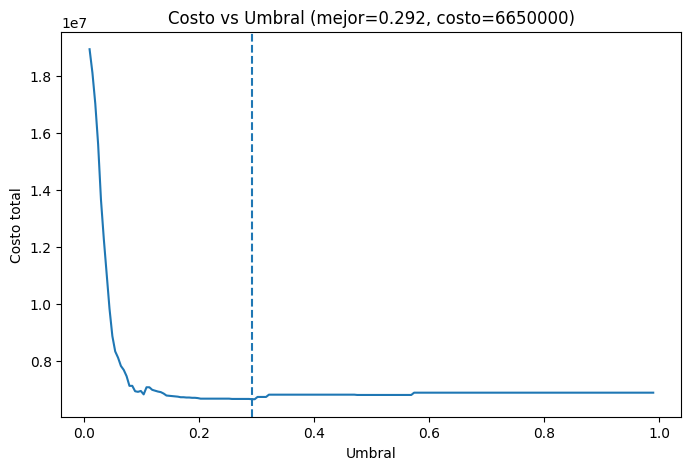

,umbral,FP,FN,costo_total,precision,recall,f1
57,0.292121,1,83,6650000,0.75,0.034884,0.066667
58,0.297071,1,83,6650000,0.75,0.034884,0.066667
50,0.257475,2,83,6660000,0.60,0.034884,0.065934
51,0.262424,2,83,6660000,0.60,0.034884,0.065934
52,0.267374,2,83,6660000,0.60,0.034884,0.065934


In [ ]:
# Ajusta estos costos según tu caso de negocio
C_FP = 10000   # costo de un Falso Positivo
C_FN = 80000  # costo de un Falso Negativo

umbrales = np.linspace(0.01, 0.99, 199)
registros = []

for th in umbrales:
    y_pred = (y_scores >= th).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    costo_total = C_FP * fp + C_FN * fn
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    registros.append([th, fp, fn, costo_total, prec, rec, f1])

costos_df = pd.DataFrame(registros, columns=["umbral","FP","FN","costo_total","precision","recall","f1"])
best_idx = costos_df["costo_total"].idxmin()
umbral_min_costo = float(costos_df.loc[best_idx, "umbral"])
costo_minimo = float(costos_df.loc[best_idx, "costo_total"])

print(f"Mejor umbral por costo = {umbral_min_costo:.3f}, costo total = {costo_minimo:.0f}")

# Gráfico costo vs umbral
plt.figure()
plt.plot(costos_df["umbral"], costos_df["costo_total"])
plt.axvline(umbral_min_costo, linestyle="--")
plt.xlabel("Umbral")
plt.ylabel("Costo total")
plt.title(f"Costo vs Umbral (mejor={umbral_min_costo:.3f}, costo={costo_minimo:.0f})")
plt.show()

# Top 5 umbrales con menor costo (útil para comparar alternativas cercanas)
costos_df.nsmallest(5, "costo_total")

Criterios alternativos: **Youden J** y **F1 máximo**
- **Youden J = TPR − FPR** (sobre la curva ROC): equilibrio entre sensibilidad y especificidad.  
- **F1 máximo**: balance entre precisión y recall; útil si quieres equilibrio entre ambos.  
- **Comparativo**: se muestran los resultados de Youden J, Mínimo Costo, F1 máximo y Umbral 0.5.


In [ ]:
# Youden J = TPR - FPR
fpr, tpr, roc_thresholds = roc_curve(y_test, y_scores)
youden_vals = tpr - fpr
idx_j = int(np.argmax(youden_vals))
umbral_youden = float(roc_thresholds[idx_j])

# Umbral que maximiza F1 (búsqueda sobre la malla de umbrales)
f1_mejor, umbral_f1 = -1.0, 0.5
for th in umbrales:
    y_pred = (y_scores >= th).astype(int)
    f1_actual = f1_score(y_test, y_pred, zero_division=0)
    if f1_actual > f1_mejor:
        f1_mejor, umbral_f1 = f1_actual, float(th)

# Resumen comparativo de criterios
def resumen_umbral(criterio, umbral):
    r = evaluar_en_umbral(y_test, y_scores, umbral)
    r['criterio'] = criterio
    return r

resumen = pd.DataFrame([
    resumen_umbral("Youden_J", umbral_youden),
    resumen_umbral("Min_Costo", umbral_min_costo),
    resumen_umbral("F1_max", umbral_f1),
    resumen_umbral("Defecto_0.5", 0.5)
])[["criterio","umbral","TP","FP","TN","FN","precision","recall","f1"]]

resumen

,criterio,umbral,TP,FP,TN,FN,precision,recall,f1
0,Youden_J,0.050839,47,546,1354,39,0.079258,0.546512,0.138439
1,Min_Costo,0.292121,3,1,1899,83,0.750000,0.034884,0.066667
2,F1_max,0.054545,40,465,1435,46,0.079208,0.465116,0.135364
3,Defecto_0.5,0.500000,1,0,1900,85,1.000000,0.011628,0.022989
